# 1. Base histórica de projetos de transformadores

**Requisito da vaga:** *Estruturar e preparar bases históricas de projetos de transformadores*.

Neste notebook carregamos a base de **projetos de engenharia** (frota sintética de 40 transformadores), examinamos distribuições, validamos regras de domínio e preparamos a base que alimenta o mecanismo de similaridade (Requisito 4).

Fonte: `dbt/seeds/transformers.csv` (gerada por `make seed`).

> **Pré-requisito:** banco local com dados (`make db && make migrate && make smoke`)
> e o ML service rodando (`make ml-run &`) — ou apenas `make demo`.
>
> Carregar o helper compartilhado (bootstrap de imports, leitores de dados,
> URLs dos serviços) da primeira célula. `notebooks/common.py`.


In [1]:
import sys
sys.path.insert(0, r'/home/carlinhoshk/dev/ETL-Telemetria-Transformadores')
sys.path.insert(0, r'/home/carlinhoshk/dev/ETL-Telemetria-Transformadores/notebooks')
import common
import pandas as pd
pd.set_option('display.max_columns', None)

design = common.load_design_base()
print(f'{design.shape[0]} projetos, {design.shape[1]} atributos')

40 projetos, 17 atributos


In [2]:
design.head()

,transformer_id,rated_power_mva,hv_voltage_kv,lv_voltage_kv,frequency_hz,phase_count,vector_group,impedance_percent,cooling_type,commissioning_year,application,no_load_loss_kw,load_loss_kw,total_mass_t,length_m,width_m,height_m
0,TR-001,35.6,115.0,11.0,60,3,YNd5,12.5,ONAF,2012,generation,46.9,370.7,52.8,4.70,3.05,4.14
1,TR-002,44.0,230.0,69.0,50,3,Dyn1,12.7,ONAF,2007,industrial,58.2,275.0,67.9,4.87,3.37,4.16
2,TR-003,30.0,138.0,13.8,60,3,Dd0,13.3,ONAF,2004,distribution,39.1,314.3,53.1,4.41,2.90,4.03
3,TR-004,39.8,69.0,34.5,60,3,Dyn1,14.1,ONAF,2022,distribution,48.8,294.5,58.6,4.82,3.12,4.10
4,TR-005,68.2,34.5,13.8,60,3,Dd0,14.4,ONAF,2023,renewable,68.4,695.4,81.5,6.25,3.95,4.68


## Inventário e tipologia

Como o escopo cobre linhas de transmissão e distribuição/industrial, olhamos os atributos qualitativos: aplicação, vetor de ligação e regime de resfriamento.

In [3]:
design.groupby(['application', 'cooling_type']).size().unstack(fill_value=0)

cooling_type,ODAF,OFAF,OFWF,ONAF,ONAN
application,,,,,
distribution,0,0,0,5,3
generation,1,2,2,3,0
industrial,0,0,0,5,0
renewable,0,2,0,7,0
transmission,1,3,0,6,0


In [4]:
design.groupby('application')['rated_power_mva'].describe().round(1)

,count,mean,std,min,25%,50%,75%,max
application,,,,,,,,
distribution,8.0,25.9,15.4,6.0,14.0,23.6,37.0,50.3
generation,8.0,136.8,83.5,35.6,49.4,160.6,182.9,261.9
industrial,5.0,47.3,18.0,32.6,39.4,41.8,44.0,78.5
renewable,9.0,69.7,37.5,22.3,28.8,68.2,101.3,114.2
transmission,10.0,95.0,62.3,52.0,62.7,69.5,79.5,244.1


## Distribuições das variáveis de projeto

Potência, tensões e ano de comissionamento guiam a faixa de similaridade.

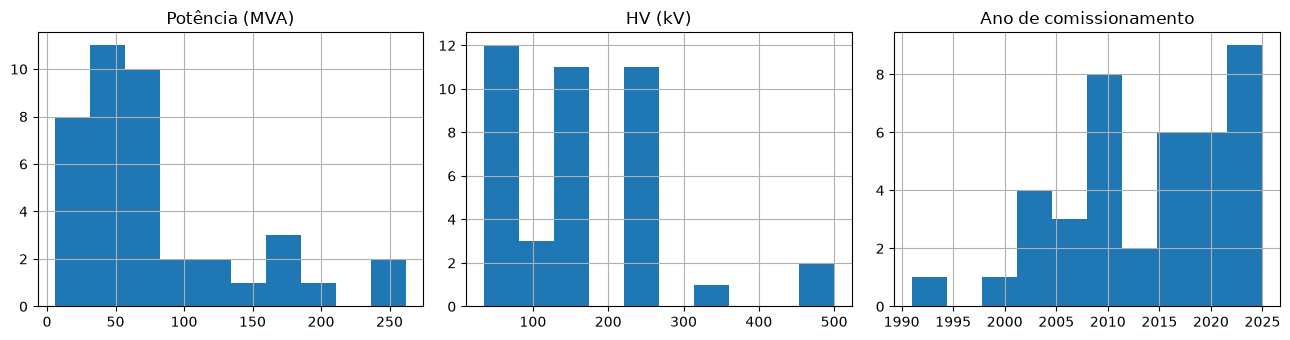

In [5]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
design['rated_power_mva'].hist(ax=axes[0]); axes[0].set_title('Potência (MVA)')
design['hv_voltage_kv'].hist(ax=axes[1]); axes[1].set_title('HV (kV)')
design['commissioning_year'].hist(ax=axes[2]); axes[2].set_title('Ano de comissionamento')
plt.tight_layout()
plt.show()

## Validação das regras de domínio

A camada de ingestão valida faixas físicas e padrões (o mesmo código de `internal/domain` em Go). Reproduzimos aqui os checks essenciais para garantir que a base histórica é limpa.

In [6]:
checks = {
    'ids únicos': design['transformer_id'].is_unique,
    'potência > 0': (design['rated_power_mva'] > 0).all(),
    'HV > LV': (design['hv_voltage_kv'] > design['lv_voltage_kv']).all(),
    'frequência 50/60 Hz': design['frequency_hz'].isin([50, 60]).all(),
    'fases 1 ou 3': design['phase_count'].isin([1, 3]).all(),
    'impedância > 0': (design['impedance_percent'] > 0).all(),
    'dimensões > 0': ((design[[c for c in design if c.endswith('_m')]] > 0)
                        .all().all()),
}
pd.Series(checks, name='ok')

ids únicos             True
potência > 0           True
HV > LV                True
frequência 50/60 Hz    True
fases 1 ou 3           True
impedância > 0         True
dimensões > 0          True
Name: ok, dtype: bool

In [7]:
# Preparação: reordenar colunas numéricas usadas pela similaridade (ordem estável).
feature_cols = common.design_features()
base_matrix = design[['transformer_id'] + feature_cols].copy()
base_matrix.shape

(40, 11)

## Conclusão

- A base histórica está estruturada e pronta para consumo analítico e pelo mecanismo de similaridade.
- Colunas numéricas de projeto em ordem estável (`docs/similarity.md`).
- Tipologia condizente com a frota sintética (transmissão e distribuição/industrial).